/home/tydaniel-bybruce/miniconda3/envs/robot/lib/python3.12/site-packages/matplotlib/animation.py:908: UserWarning: Animation was deleted without rendering anything. This is most likely not intended. To prevent deletion, assign the Animation to a variable, e.g. `anim`, that exists until you output the Animation using `plt.show()` or `anim.save()`.
  warnings.warn(


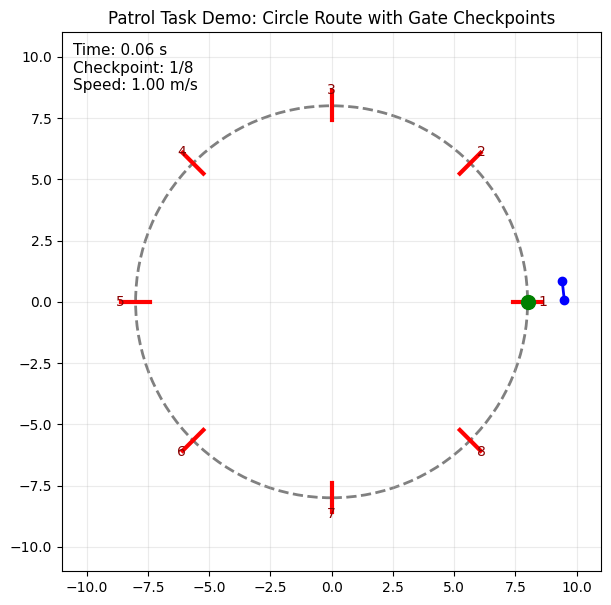

In [2]:
import numpy as np
import matplotlib.pyplot as plt
from matplotlib.animation import FuncAnimation

# -----------------------------
# Problem setup
# -----------------------------
R = 8.0                      # route radius
center = np.array([0.0, 0.0])

num_checkpoints = 8
angles = np.linspace(0, 2*np.pi, num_checkpoints, endpoint=False)

# Checkpoint gates are radial segments around the circle
gate_width = 1.2             # gate width in meters
gate_half = gate_width / 2

# Vehicle initial state
x = R + 1.5
y = 0.0
theta = np.pi / 2            # heading angle
v = 1.2                      # initial speed

# Control limits
v_max = 3.0
v_min = 0.4
w_max = 1.8

dt = 0.03
k_heading = 2.2
k_speed = 1.0

# Navigation state
current_cp = 0
passed = np.zeros(num_checkpoints, dtype=bool)
done = False
t = 0.0

# -----------------------------
# Helper functions
# -----------------------------
def wrap_to_pi(a):
    return (a + np.pi) % (2*np.pi) - np.pi

def checkpoint_pos(i):
    ang = angles[i]
    return np.array([R*np.cos(ang), R*np.sin(ang)])

def checkpoint_tangent(i):
    ang = angles[i]
    # Tangent direction for counter-clockwise traversal
    return np.array([-np.sin(ang), np.cos(ang)])

def checkpoint_normal(i):
    ang = angles[i]
    # Radial outward normal
    return np.array([np.cos(ang), np.sin(ang)])

def gate_endpoints(i):
    p = checkpoint_pos(i)
    n = checkpoint_normal(i)
    e1 = p - gate_half*n
    e2 = p + gate_half*n
    return e1, e2

def crossed_gate(prev_pos, pos, i):
    """
    Gate crossing test:
    We consider crossing the radial gate line segment near the checkpoint.
    For a simple demo, check if the vehicle moved from one side to the other
    of the gate's tangent line AND is close enough to the checkpoint.
    """
    p_gate = checkpoint_pos(i)
    n = checkpoint_normal(i)

    prev_side = np.dot(prev_pos - p_gate, n)
    curr_side = np.dot(pos - p_gate, n)

    # Crossing gate line means sign change around the radial line
    sign_change = (prev_side <= 0 and curr_side >= 0) or (prev_side >= 0 and curr_side <= 0)

    # Check proximity to the gate center
    dist_to_gate = np.linalg.norm(pos - p_gate)

    return sign_change and (dist_to_gate < 1.5)

# -----------------------------
# Figure setup
# -----------------------------
fig, ax = plt.subplots(figsize=(7, 7))
ax.set_aspect('equal')
ax.set_xlim(-R-3, R+3)
ax.set_ylim(-R-3, R+3)
ax.grid(True, alpha=0.25)

# Route circle
circle = plt.Circle((0, 0), R, fill=False, linestyle='--', linewidth=2, color='gray')
ax.add_patch(circle)

# Checkpoint gates
gate_lines = []
for i in range(num_checkpoints):
    e1, e2 = gate_endpoints(i)
    line, = ax.plot([e1[0], e2[0]], [e1[1], e2[1]], 'r-', lw=3)
    gate_lines.append(line)
    p = checkpoint_pos(i)
    ax.text(p[0]*1.08, p[1]*1.08, str(i+1), color='darkred', fontsize=10, ha='center', va='center')

# Vehicle body
vehicle_plot, = ax.plot([], [], 'bo-', lw=2, markersize=6)
trail_plot, = ax.plot([], [], 'b-', lw=1, alpha=0.5)
trail = []

# Current target marker
target_plot, = ax.plot([], [], 'go', markersize=10)

# Text info
info_text = ax.text(0.02, 0.98, '', transform=ax.transAxes, va='top', fontsize=11)

# -----------------------------
# Animation update
# -----------------------------
def update(frame):
    global x, y, theta, v, current_cp, done, t, trail, passed

    if done:
        # Keep drawing final state
        vehicle_plot.set_data([x], [y])
        if trail:
            tr = np.array(trail)
            trail_plot.set_data(tr[:, 0], tr[:, 1])
        info_text.set_text(f"Finished in {t:.2f} s")
        return vehicle_plot, trail_plot, target_plot, info_text

    prev_pos = np.array([x, y])

    # Current checkpoint target
    target = checkpoint_pos(current_cp)
    vec = target - np.array([x, y])
    desired_heading = np.arctan2(vec[1], vec[0])
    heading_error = wrap_to_pi(desired_heading - theta)

    # Steering control
    w = np.clip(k_heading * heading_error, -w_max, w_max)

    # Speed control:
    # faster when aligned with target, slower when turning sharply
    alignment = np.cos(heading_error)
    v_des = v_min + (v_max - v_min) * max(0.0, alignment)
    v += np.clip(k_speed * (v_des - v), -0.1, 0.1)
    v = np.clip(v, v_min, v_max)

    # Kinematic point-car model update
    x += v * np.cos(theta) * dt
    y += v * np.sin(theta) * dt
    theta += w * dt
    theta = wrap_to_pi(theta)

    t += dt
    trail.append([x, y])

    # Check gate passing
    if crossed_gate(prev_pos, np.array([x, y]), current_cp):
        passed[current_cp] = True
        current_cp += 1

        if current_cp >= num_checkpoints:
            done = True
            current_cp = num_checkpoints - 1

    # Draw vehicle orientation
    L = 0.8
    body_x = [x, x + L*np.cos(theta)]
    body_y = [y, y + L*np.sin(theta)]
    vehicle_plot.set_data(body_x, body_y)

    # Trail
    tr = np.array(trail)
    trail_plot.set_data(tr[:, 0], tr[:, 1])

    # Target
    target_plot.set_data([target[0]], [target[1]])

    info_text.set_text(
        f"Time: {t:.2f} s\n"
        f"Checkpoint: {min(current_cp+1, num_checkpoints)}/{num_checkpoints}\n"
        f"Speed: {v:.2f} m/s"
    )

    return vehicle_plot, trail_plot, target_plot, info_text

ani = FuncAnimation(fig, update, frames=3000, interval=20, blit=True)
plt.title("Patrol Task Demo: Circle Route with Gate Checkpoints")
plt.show()